In [1]:
# =============================================================================
# Window Sensitivity Analysis
# Vary window length and overlap ratio; evaluate RF under LOPO.
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Python.integrations import load_gym_dataset
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── Load & clean data ─────────────────────────────────────────────────────────
print("Loading dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))

SENSOR_COLS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "grav_x", "grav_y", "grav_z",
    "magnet_x", "magnet_y", "magnet_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]
total_missing = int(raw_data[SENSOR_COLS].isnull().sum().sum())
if total_missing > 0:
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(lambda g: g.interpolate(method="linear").ffill().bfill())
    )
print(f"Loaded {len(raw_data):,} samples — participants: {sorted(raw_data['participant'].unique())}")

Loading dataset...
Gym Movements Dataset loaded:
  Total samples : 221,681
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 88
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']
Loaded 221,681 samples — participants: ['imaan', 'richard']


  window=64 overlap=0.25 ...  
Window creation summary:
  Full-size windows: 4547
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 4547
  Processing window 0/4547...
  Processing window 100/4547...
  Processing window 200/4547...
  Processing window 300/4547...
  Processing window 400/4547...
  Processing window 500/4547...
  Processing window 600/4547...
  Processing window 700/4547...
  Processing window 800/4547...
  Processing window 900/4547...
  Processing window 1000/4547...
  Processing window 1100/4547...
  Processing window 1200/4547...
  Processing window 1300/4547...
  Processing window 1400/4547...
  Processing window 1500/4547...
  Processing window 1600/4547...
  Processing window 1700/4547...
  Processing window 1800/4547...
  Processing window 1900/4547...
  Processing window 2000/4547...
  Processing window 2100/4547...
  Processing window 2200/4547...
  Processing window 2300/4547...
  Processing window 2400/4547...
  Processing window 2500/4547...
  Pro

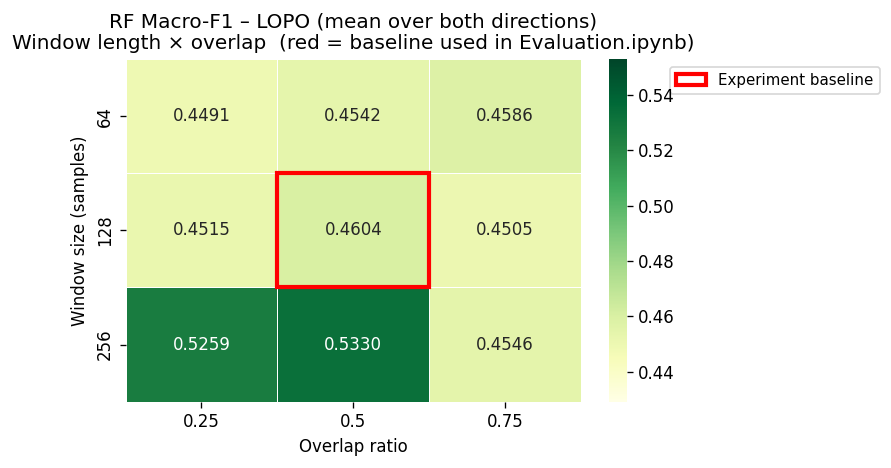


=== Window sensitivity summary (LOPO) ===


Overlap ratio,0.25,0.50,0.75
Window size (samples),,,
64,0.4491,0.4542,0.4586
128,0.4515,0.4604,0.4505
256,0.5259,0.5330,0.4546


In [2]:
# ── Window sensitivity analysis (LOPO) ───────────────────────────────────────
# Train on all data from participant A, test on participant B, and vice versa.
# Score = mean macro-F1 across both LOPO directions.
# Runtime: ~2–4 min (feature extraction + RF × 9 combos × 2 directions).

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score as sk_f1

WINDOW_SIZES   = [64, 128, 256]   # samples @ 50 Hz → 1.28 s, 2.56 s, 5.12 s
OVERLAP_RATIOS = [0.25, 0.5, 0.75]
BASELINE_WS, BASELINE_OV = 128, 0.5

_window_grid = {}

for ws in WINDOW_SIZES:
    for ov in OVERLAP_RATIOS:
        print(f"  window={ws} overlap={ov} ...", end="  ", flush=True)
        wd  = create_adaptive_windows(
            raw_data,
            min_window_size       = ws // 2,
            preferred_window_size = ws,
            overlap_ratio         = ov,
        )
        f, l, _, m = engineer_robust_features(wd, sampling_rate=50)

        le           = LabelEncoder()
        y            = le.fit_transform(l)
        participants = np.array([md["participant"] for md in m])
        unique_ps    = np.unique(participants)

        scores = []
        for test_p in unique_ps:
            tr = participants != test_p
            te = participants == test_p
            sc  = StandardScaler().fit(f[tr])
            clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
            clf.fit(sc.transform(f[tr]), y[tr])
            scores.append(sk_f1(y[te], clf.predict(sc.transform(f[te])), average="macro"))

        _window_grid[(ws, ov)] = round(float(np.mean(scores)), 4)
        print(f"macro_f1={_window_grid[(ws, ov)]:.4f}  n_windows={len(wd)}")

# ── Heatmap ───────────────────────────────────────────────────────────────────
_grid_df = pd.DataFrame(
    {ov: {ws: _window_grid[(ws, ov)] for ws in WINDOW_SIZES} for ov in OVERLAP_RATIOS}
)
_grid_df.index.name   = "Window size (samples)"
_grid_df.columns.name = "Overlap ratio"

_vmin = max(0.0, min(_window_grid.values()) - 0.02)
_vmax = min(1.0, max(_window_grid.values()) + 0.02)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(_grid_df, annot=True, fmt=".4f", cmap="YlGn", ax=ax,
            linewidths=0.5, vmin=_vmin, vmax=_vmax)

_col = OVERLAP_RATIOS.index(BASELINE_OV)
_row = WINDOW_SIZES.index(BASELINE_WS)
ax.add_patch(plt.Rectangle((_col, _row), 1, 1, fill=False,
                            edgecolor="red", lw=2.5, label="Experiment baseline"))
ax.legend(loc="upper left", bbox_to_anchor=(1.18, 1.0), fontsize=9)
ax.set_title("RF Macro-F1 – LOPO (mean over both directions)\n"
             "Window length × overlap  (red = baseline used in Evaluation.ipynb)")
ax.set_xlabel("Overlap ratio")
ax.set_ylabel("Window size (samples)")
plt.tight_layout()
plt.savefig("./Plots/window_sensitivity_lopo.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Window sensitivity summary (LOPO) ===")
display(_grid_df)